In [7]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

In [9]:
dfv = pd.read_csv("./data/flow_10.23-03.24.csv")
dfv.loc[:,'timestamp'] = pd.to_datetime(dfv['timestamp'], errors='coerce')
dfv.set_index("timestamp",inplace=True)

c:\Program Files\Python311\Lib\site-packages\pandas\core\indexes\base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


In [10]:
volume_col = []
for i in dfv.columns:
    if 'total_flow' in i:
        volume_col.append(i)
len(volume_col)
     

768

In [11]:
df = pd.read_csv('./result_csv/data_matrix.csv')    
to_remove = pd.read_csv('./result_csv/to_remove.csv')
df.loc[:,'timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df.set_index("timestamp",inplace=True)
df.drop(columns=list(to_remove['to_remove']), inplace=True)

c:\Program Files\Python311\Lib\site-packages\pandas\core\indexes\base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


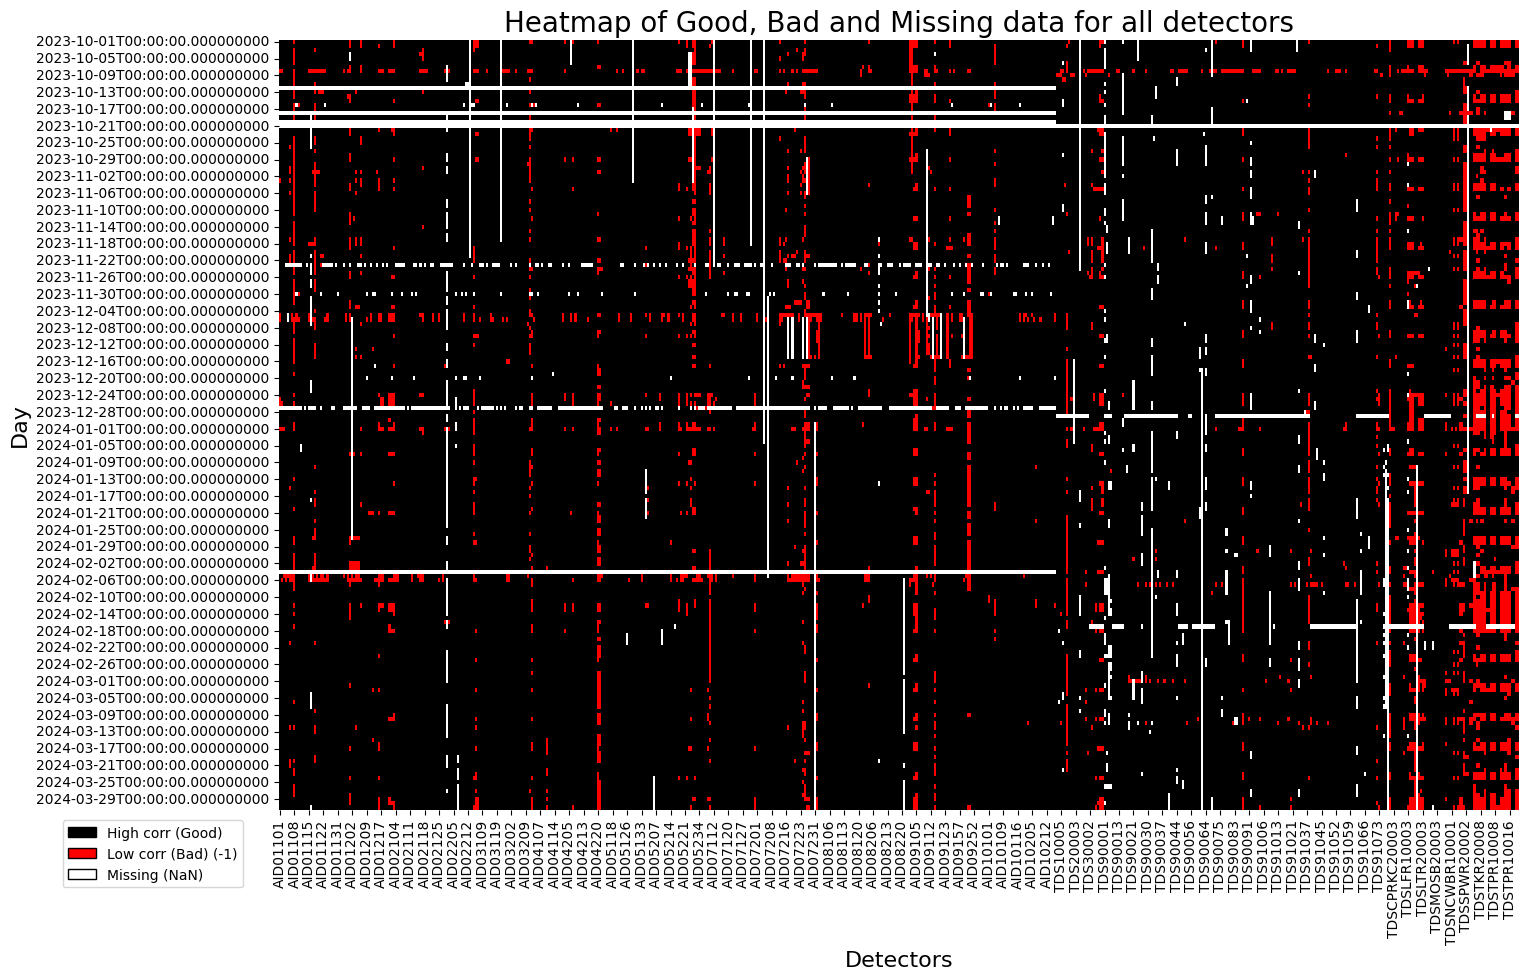

In [12]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
custom_colors = ['red', 'white', 'black']  # order is -1, NaN, +1
custom_cmap = ListedColormap(custom_colors)

plt.figure(figsize=(16,10))
sns.heatmap(df, cmap=custom_cmap, cbar=False)
plt.title('Heatmap of Good, Bad and Missing data for all detectors', fontsize = 20)
legend_elements = [
    Patch(facecolor='black', edgecolor='black', label='High corr (Good)'),
    Patch(facecolor='red', edgecolor='black', label='Low corr (Bad) (-1)'),
    Patch(facecolor='white', edgecolor='black', label='Missing (NaN)')
]

# Add legend to the plot
plt.legend(handles=legend_elements, loc='lower left', bbox_to_anchor=(-0.18, -0.11))
plt.xlabel('Detectors', fontsize=16)
plt.ylabel('Day', fontsize=16)
plt.show()

In [13]:
from sklearn.preprocessing import OneHotEncoder

# Function to create one-hot encoded labels for day of week
def create_one_hot_labels(detectors):
    enc = OneHotEncoder(sparse_output=False)
    detectors_reshaped = np.array(detectors).reshape(-1, 1)
    enc.fit(detectors_reshaped)
    return enc

In [14]:
detectors = df.columns.tolist()
one_hot_encoder = create_one_hot_labels(detectors)
one_hot_encoder

OneHotEncoder(sparse_output=False)

In [15]:
# The data has only <5% null values which we are filling with 0
dfv = dfv.fillna(0)

In [16]:
X = []
y = []

# Iterate over each detector
for day in df.index:
    for detector in detectors:
        if df.at[day, detector] == 1:
            start = day
            end = start + pd.Timedelta(days=1) - pd.Timedelta(minutes=2)
            weekday_number = start.date().weekday()
            one_hot_day = np.eye(7)[1]

            # Get data for the current day
            daily_data = dfv[start:end][detector+'_total_flow'].values

            if len(daily_data) == 720:  # Ensure we have exactly 720 samples (24 hours * 30 samples per hour)
                # Append daily data and corresponding label
                features = np.hstack((one_hot_day, daily_data))

                X.append(features)
                y.append(one_hot_encoder.transform([[detector]])[0])
            else:
                print("error")
                
X = np.array(X, dtype=np.float32) 
y = np.array(y, dtype=np.float32)  

print("X shape:", X.shape)  # Should be (number of samples, 720)
print("y shape:", y.shape)

X shape: (100098, 727)
y shape: (100098, 600)


In [17]:
X_train, X_test_full, y_train, y_test_full = train_test_split(X, y, test_size=0.3, random_state=5)
X_test, X_val, y_test, y_val = train_test_split(X_test_full, y_test_full, test_size=0.5, random_state=6)

scaler = StandardScaler()

X_train_normalized = scaler.fit_transform(X_train)
X_train_tensor = torch.tensor(X_train_normalized)
y_train_tensor = torch.tensor(y_train)

X_val_normalized = scaler.transform(X_val)
X_val_tensor = torch.tensor(X_val_normalized)
y_val_tensor = torch.tensor(y_val)

X_test_normalized = scaler.transform(X_test)
X_test_tensor = torch.tensor(X_test_normalized)
y_test_tensor = torch.tensor(y_test)

num_classes = y_test_tensor.shape[1]

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

X_train shape: (70068, 727)
X_val shape: (15015, 727)
X_test shape: (15015, 727)
y_train shape: (70068, 600)
y_val shape: (15015, 600)
y_test shape: (15015, 600)


In [37]:
class MLP(nn.Module):
    def __init__(self,num_classes):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(721, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = self.fc4(x)
        return x

In [38]:
class DeepBottle(nn.Module):
    def __init__(self,num_classes):
        super(DeepBottle, self).__init__()
        self.fc1 = nn.Linear(727, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 32)
        self.fc5 = nn.Linear(32, 128)
        self.fc6 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = torch.relu(self.fc4(x))
        x = torch.relu(self.fc5(x))
        x = self.fc6(x)
     
        return x

In [39]:
class ComplexMLP(nn.Module):
    def __init__(self,num_classes):
        super(ComplexMLP, self).__init__()
        self.fc1 = nn.Linear(727, 128)
        self.fc2 = nn.Linear(128, 32)  
        self.fc3 = nn.Linear(32, 128)
        self.fc4 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = self.fc4(x)
        return x

In [21]:
class MLP_attention(nn.Module):
    def __init__(self,num_classes):
        super(MLP_attention, self).__init__()
        # Branch for day of the week
        self.day_branch = nn.Sequential(
            nn.Linear(7, 32),  # Processing numeric day of week
            nn.ReLU(),
            nn.Linear(32, 32),  
            nn.ReLU(),
        )
        
        # Branch for other features
        self.feature_branch = nn.Sequential(
            nn.Linear(720, 128),  # Assuming 720 other features
            nn.ReLU(),
            # nn.Linear(128, 128),
            # nn.ReLU(),
        )
        
        # Combine branches
        self.combined_branch = nn.Sequential(
            nn.Linear(32 + 128, 32),
            nn.ReLU(),
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)  # Output layer
        )

    def forward(self, x):
        day_features = x[:, :7]  # Assuming first column is the numeric day of the week
        other_features = x[:, 7:]  # Rest are other features
        
        day_output = self.day_branch(day_features)
        feature_output = self.feature_branch(other_features)
        
        combined = torch.cat((day_output, feature_output), dim=1)
        output = self.combined_branch(combined)
        
        return output

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [23]:
X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
X_val_tensor = X_val_tensor.to(device)
y_val_tensor = y_val_tensor.to(device)

In [43]:
model = MLP_attention(num_classes).to(device)
model_name = model.__class__.__name__
criterion = nn.CrossEntropyLoss()
lr = 0.001
wd = 0.001
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Variables to track highest val accuracy and corresponding model state
highest_val_accuracy = 0.0
epochs = 3000
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    total_predictions = 0
    correct_predictions = 0

    # Forward pass
    outputs = model(X_train_tensor)
    
    # Compute training loss
    loss = criterion(outputs, y_train_tensor)
    
    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Calculate training loss
    running_loss = loss.item()

    # Compute training predictions and accuracy
    _, predicted_train = torch.max(outputs, 1)
    total_predictions_train = y_train_tensor.size(0)
    correct_predictions_train = (predicted_train == y_train_tensor.argmax(dim=1)).sum().item()  # Convert one-hot encoded labels to class indices
    
    # Calculate training accuracy
    accuracy_train = correct_predictions_train / total_predictions_train
    
    # Evaluate the model on the valing data
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():  # Disable gradient calculation
        outputs_val = model(X_val_tensor)
        val_loss = criterion(outputs_val, y_val_tensor)
        _, predicted_val = torch.max(outputs_val, 1)
        total_predictions_val = y_val_tensor.size(0)
        correct_predictions_val = (predicted_val == y_val_tensor.argmax(dim=1)).sum().item()
        accuracy_val = correct_predictions_val / total_predictions_val
    
    # Append current epoch loss and accuracy to arrays
    train_losses.append(running_loss)
    val_losses.append(val_loss.item())
    train_accuracies.append(accuracy_train)
    val_accuracies.append(accuracy_val)
    
    if accuracy_val > highest_val_accuracy:
        # Update highest val accuracy and save model state
        highest_val_accuracy = accuracy_val
        torch.save(model.state_dict(),'./model_profile/' + model_name + '_lr-' + str(lr) + '_wd-' + str(wd) + '.pth')
    
    if (epoch + 1) % 50 == 0:
        # Print epoch loss and accuracy for both training and valing
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {running_loss}, val Loss: {val_loss.item()}, Train Accuracy: {accuracy_train}, val Accuracy: {accuracy_val}")
    
    elif (epoch + 1) == epochs:
        # Print final epoch loss and accuracy for training
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {running_loss}, val Loss: {val_loss.item()}, Train Accuracy: {accuracy_train}, val Accuracy: {accuracy_val}")
print('Highest val Accuracy : ', highest_val_accuracy)
# Save the best model state to a file



Epoch 50/3000, Train Loss: 4.364232540130615, val Loss: 4.34491491317749, Train Accuracy: 0.06853342467317464, val Accuracy: 0.06733266733266734
Epoch 100/3000, Train Loss: 2.75070858001709, val Loss: 2.806896686553955, Train Accuracy: 0.3008791459724839, val Accuracy: 0.2887112887112887
Epoch 150/3000, Train Loss: 2.1093037128448486, val Loss: 2.21826171875, Train Accuracy: 0.4283553119826454, val Accuracy: 0.3992007992007992
Epoch 200/3000, Train Loss: 1.7744113206863403, val Loss: 1.932877540588379, Train Accuracy: 0.5015699035222926, val Accuracy: 0.46027306027306025
Epoch 250/3000, Train Loss: 1.5846208333969116, val Loss: 1.7805362939834595, Train Accuracy: 0.5412313752354855, val Accuracy: 0.4919080919080919
Epoch 300/3000, Train Loss: 1.4627941846847534, val Loss: 1.6897753477096558, Train Accuracy: 0.5666638122966261, val Accuracy: 0.5074925074925075
Epoch 350/3000, Train Loss: 1.367422103881836, val Loss: 1.6214911937713623, Train Accuracy: 0.5858309071187989, val Accuracy: 0

In [44]:
model = MLP_attention(num_classes).to(device) 
criterion = nn.CrossEntropyLoss()
epochs = 3000
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)
model.load_state_dict(torch.load('./model_profile/MLP_attention_lr-0.001_wd-0.001.pth'))
model.eval()  # Set the model to evaluation mode
with torch.no_grad():  # Disable gradient calculation
    outputs_test = model(X_test_tensor)
    test_loss = criterion(outputs_test, y_test_tensor)
    _, predicted_test = torch.max(outputs_test, 1)
    total_predictions_test = y_test_tensor.size(0)
    correct_predictions_test = (predicted_test == y_test_tensor.argmax(dim=1)).sum().item()
    accuracy_test = correct_predictions_test / total_predictions_test

    outputs_val = model(X_val_tensor)
    val_loss = criterion(outputs_val, y_val_tensor)
    _, predicted_val = torch.max(outputs_val, 1)
    total_predictions_val = y_val_tensor.size(0)
    correct_predictions_val = (predicted_val == y_val_tensor.argmax(dim=1)).sum().item()
    accuracy_val = correct_predictions_val / total_predictions_val
    
print('Test acc : ',accuracy_test,',  Val acc : ',accuracy_val)

Test acc :  0.5922077922077922 ,  Val acc :  0.5946053946053946


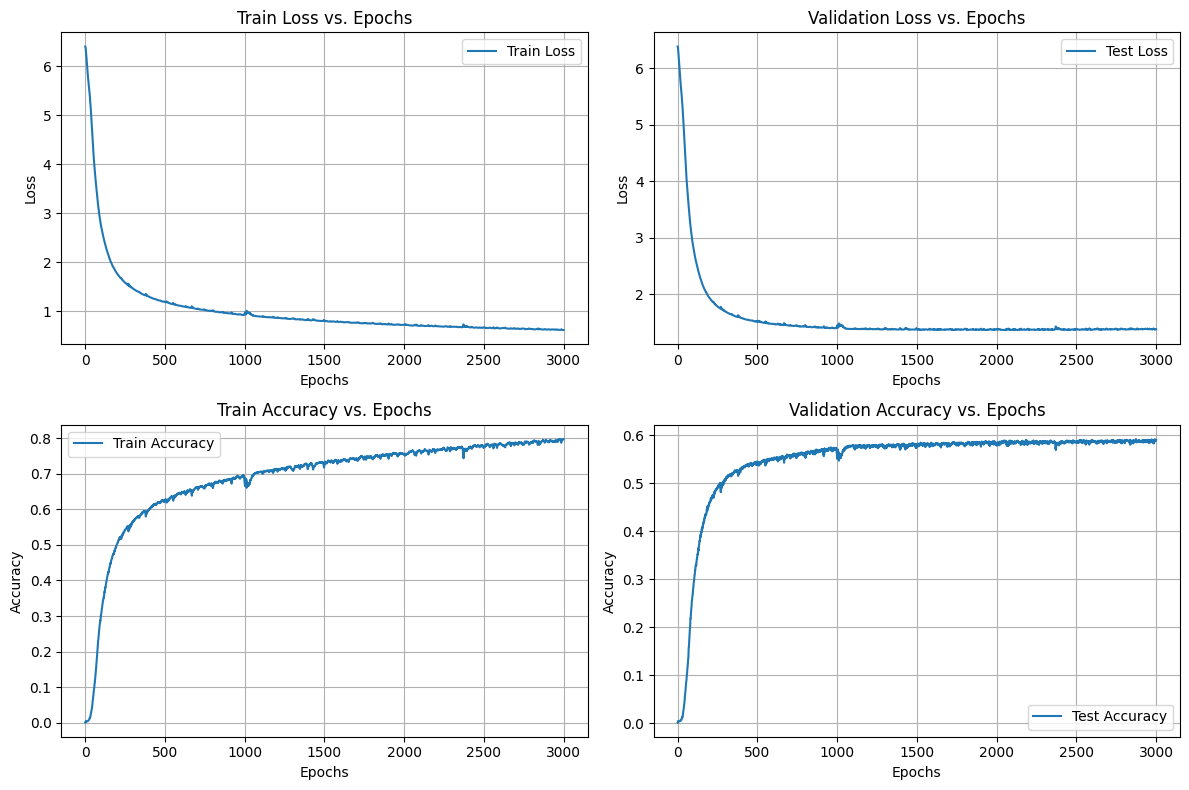

In [45]:
epochs_range = range(1, epochs + 1)
# epochs_range = range(1,900)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train Loss vs. Epochs')
plt.grid(True)
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(epochs_range, val_losses, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Validation Loss vs. Epochs')
plt.grid(True)
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(epochs_range, train_accuracies, label='Train Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Train Accuracy vs. Epochs')
plt.grid(True)
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(epochs_range, val_accuracies, label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy vs. Epochs')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [27]:
# We find different accuracies for different k values.
# The accuray represent top-k accuracy i.e. when prediction lies in top k values then it is correct prediction
accuracies = []
k_values = range(1, 30)

with torch.no_grad():
    outputs_test = model(X_test_tensor)
    total_predictions_test = y_test_tensor.size(0)
    
    for k in k_values:
        _, predicted_test = torch.topk(outputs_test, k, dim=1)
        correct_predictions_test = (y_test_tensor.gather(1, predicted_test) == 1).any(dim=1).sum().item()
        accuracy_test = correct_predictions_test / total_predictions_test
        accuracies.append(accuracy_test)

print(accuracies)


[0.5922077922077922, 0.7798867798867799, 0.856010656010656, 0.8971694971694971, 0.9210789210789211, 0.9341325341325342, 0.9433899433899434, 0.9511155511155511, 0.9573759573759574, 0.9619047619047619, 0.9655677655677656, 0.9681651681651682, 0.9708291708291709, 0.9726939726939727, 0.974025974025974, 0.9751581751581752, 0.9765567765567765, 0.9780885780885781, 0.9788211788211788, 0.9793539793539794, 0.9802197802197802, 0.9812187812187813, 0.981951381951382, 0.9823509823509824, 0.983016983016983, 0.9837495837495838, 0.9838161838161839, 0.9842823842823842, 0.9846153846153847]


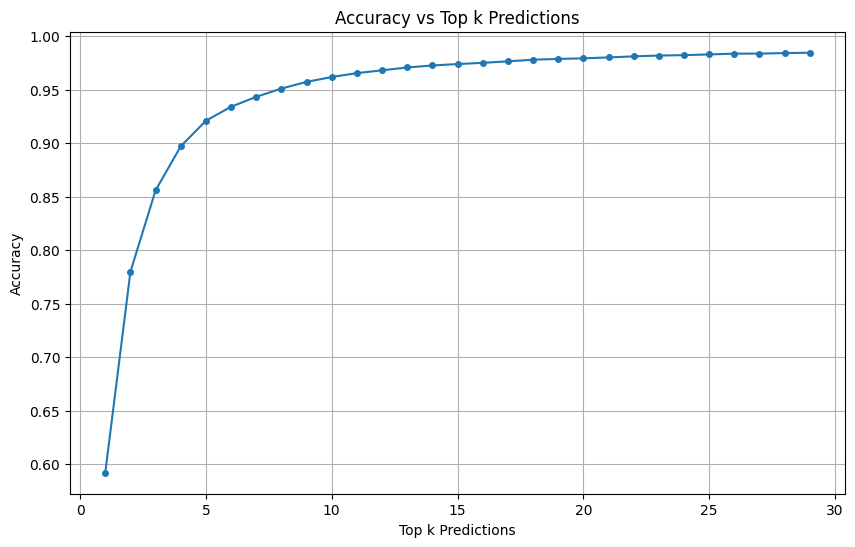

In [28]:
# Plotting the graph for accuracy with different k values
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='-', markersize=4)
plt.xlabel('Top k Predictions')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Top k Predictions')
plt.grid(True)
plt.show()

In [29]:
model.eval()
with torch.no_grad():
    outputs_test = model(X_test_tensor)
    _, predicted_test = torch.max(outputs_test, 1)

# Convert predictions and true labels to numpy arrays
predictions = predicted_test.cpu().numpy()
true_labels = y_test_tensor.argmax(dim=1).cpu().numpy()

# Compute the confusion matrix
conf_matrix = confusion_matrix(true_labels, predictions)

In [30]:
# Print classification report
class_report = classification_report(true_labels, predictions, target_names=detectors)
print(class_report)

               precision    recall  f1-score   support

     AID01101       0.86      1.00      0.92        24
     AID01102       0.79      0.73      0.76        26
     AID01103       0.86      0.90      0.88        21
     AID01104       0.88      0.85      0.86        33
     AID01105       0.78      0.72      0.75        25
     AID01106       0.47      0.43      0.45        21
     AID01107       0.52      0.62      0.57        24
     AID01108       0.92      0.69      0.79        16
     AID01109       0.83      0.89      0.86        28
     AID01110       0.87      0.93      0.90        28
     AID01111       0.43      0.24      0.31        25
     AID01112       0.57      0.76      0.65        33
     AID01113       0.44      0.59      0.51        27
     AID01114       0.62      0.53      0.57        30
     AID01115       0.88      0.58      0.70        26
     AID01116       0.77      0.96      0.85        24
     AID01117       0.90      0.78      0.84        23
     AID0

# Analysis

In [46]:
df_triplets = pd.read_csv('./result_csv/triplets.csv')
df_duets = pd.read_csv('./result_csv/duets.csv')
print(df_triplets.to_string())

                  0               1               2
0          AID01101        AID01102        AID01103
1          AID01102        AID01103        AID01104
2          AID01103        AID01104        AID01105
3          AID01104        AID01105        AID01106
4          AID01105        AID01106        AID01107
5          AID01108        AID01109        AID01110
6          AID01111        AID01112        AID01113
7          AID01112        AID01113        AID01114
8          AID01113        AID01114        AID01115
9          AID01114        AID01115        AID01116
10         AID01115        AID01116        AID01117
11         AID01116        AID01117        AID01118
12         AID01117        AID01118        AID01119
13         AID01118        AID01119        AID01120
14         AID01119        AID01120        AID01121
15         AID01120        AID01121        AID01122
16         AID01121        AID01122        AID01123
17         AID01124        AID01125        AID01126
18         A

In [27]:
# This snippet finds the correlation for each day for each detector and stores in a matrix df_new

# df_new = df.copy()
# for idx in df.index:
#     for i in df.columns:

#         if(df.loc[idx,i]==np.nan):
#             df_new.loc[idx,i]=np.nan
#             continue

#         corr = 0
#         row_id_0 = df_triplets.index[df_triplets['0'].isin([i])]
#         row_id_1 = df_triplets.index[df_triplets['1'].isin([i])]
#         row_id_2 = df_triplets.index[df_triplets['2'].isin([i])]
#         if(not(row_id_1.empty)):
#             det = df_triplets.loc[row_id_1].values.flatten().tolist()
#             t1 = det[0]+'_total_flow' in dfv.columns
#             t3 = det[2]+'_total_flow' in dfv.columns

#             if(t1 and t3):
#                 det1 = dfv.loc[idx: idx + pd.DateOffset(days=1),det[0]+'_total_flow']
#                 det2 = dfv.loc[idx: idx + pd.DateOffset(days=1),det[1]+'_total_flow']
#                 det3 = dfv.loc[idx: idx + pd.DateOffset(days=1),det[2]+'_total_flow']

#                 corr = (det2.corr(det1) + det2.corr(det3))/2
#             elif(t1 and not(t3)):
#                 det1 = dfv.loc[idx: idx + pd.DateOffset(days=1),det[0]+'_total_flow']
#                 det2 = dfv.loc[idx: idx + pd.DateOffset(days=1),det[1]+'_total_flow']

#                 corr = det2.corr(det1)
#             elif(t3 and not(t1)):
#                 det2 = dfv.loc[idx: idx + pd.DateOffset(days=1),det[1]+'_total_flow']
#                 det3 = dfv.loc[idx: idx + pd.DateOffset(days=1),det[2]+'_total_flow']

#                 corr = det2.corr(det3)                    

#         elif(not(row_id_0.empty)):
#             det = df_triplets.loc[row_id_0].values.flatten().tolist()
#             det1 = dfv.loc[idx: idx + pd.DateOffset(days=1),det[0]+'_total_flow']
#             det2 = dfv.loc[idx: idx + pd.DateOffset(days=1),det[1]+'_total_flow']

#             corr = det2.corr(det1)

#         elif(not(row_id_2.empty)):
#             det = df_triplets.loc[row_id_2].values.flatten().tolist()
#             det2 = dfv.loc[idx: idx + pd.DateOffset(days=1),det[1]+'_total_flow']
#             det3 = dfv.loc[idx: idx + pd.DateOffset(days=1),det[2]+'_total_flow']

#             corr = det2.corr(det3)

#         df_new.loc[idx,i] = corr

c:\Program Files\Python311\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Program Files\Python311\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Program Files\Python311\Lib\site-packages\numpy\lib\function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Program Files\Python311\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Program Files\Python311\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


In [47]:
# df_new.to_csv('./result_csv/corr_matrix_profile.csv')
df_new = pd.read_csv('./result_csv/corr_matrix_profile.csv')
df_new

,timestamp,AID01101,AID01102,AID01103,AID01104,AID01105,AID01106,AID01107,AID01108,AID01109,...,TDSTPR10010,TDSTPR10011,TDSTPR10012,TDSTPR10014,TDSTPR10015,TDSTPR10016,TDSTTR10002,TDSTTR10003,TDSYSR20001,TDSYSR20002
0,2023-10-01,0.898650,0.903773,0.924215,0.949711,0.929371,0.923459,0.948063,0.888193,0.920076,...,0.860247,0.829559,0.771167,0.741078,0.784739,0.851991,0.799412,0.925809,0.784472,0.777367
1,2023-10-02,0.917417,0.918258,0.926319,0.949054,0.923531,0.911870,0.941248,0.893611,0.924538,...,0.838971,0.815746,0.768317,0.750944,0.797146,0.862746,0.836728,0.944220,0.824933,0.780471
2,2023-10-03,0.939282,0.938133,0.944379,0.963134,0.949856,0.938065,0.950912,0.887691,0.914521,...,0.933447,0.925797,0.878045,0.870737,0.865943,0.904469,0.891608,0.958729,0.902003,0.872177
3,2023-10-04,0.946456,0.942767,0.945526,0.964086,0.922714,0.891900,0.914571,0.791977,0.871804,...,0.936813,0.921717,0.906283,0.888901,0.867825,0.912099,0.890228,0.959677,0.908821,0.884080
4,2023-10-05,0.943975,0.943677,0.942314,0.952099,0.919946,0.901238,0.925534,0.842660,0.893094,...,0.931719,0.919157,0.905710,0.876034,0.863132,0.903362,0.881692,0.935905,0.891621,0.870901
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,2024-03-27,0.944450,0.940595,0.944701,0.961098,0.943947,0.943090,0.967822,0.883983,0.920779,...,0.916853,0.896865,0.822445,0.822242,0.832665,0.874578,0.878005,0.947728,0.887871,0.877995
179,2024-03-28,0.939972,0.932141,0.933611,0.956063,0.938642,0.926746,0.945421,0.884165,0.913656,...,0.900810,0.885527,0.858466,0.811626,0.817487,0.876626,0.873557,0.943267,0.885430,0.863804
180,2024-03-29,0.915305,0.917319,0.927474,0.946887,0.918146,0.912283,0.946432,0.905797,0.930976,...,0.844896,0.820285,0.767018,0.765611,0.790777,0.857692,0.813672,0.934039,0.824753,0.786753
181,2024-03-30,0.901829,0.901063,0.911921,0.941404,0.927358,0.920489,0.945525,0.909746,0.931599,...,0.865529,0.840713,0.753863,0.747827,0.778203,0.859564,0.814344,0.930803,0.828434,0.760672


In [48]:
scatter_data_corr = []
scatter_data_acc = []

In [49]:
df_result = pd.DataFrame(np.nan, index=df.index, columns=df.columns)
num_classes = 600

In [ ]:
# model = MLP_attention(num_classes).to(device) 
# criterion = nn.CrossEntropyLoss()
# model.load_state_dict(torch.load('./model_profile/MLP_attention_lr-0.001_wd-0.001.pth'))
# model.eval()  # Set the model to evaluation mode

# for idx in df.index:
#     for i in df.columns:

#         if(df.loc[idx,i]==np.nan):
#             continue
        
#         start = idx
#         end = start + pd.Timedelta(days=1) - pd.Timedelta(minutes=2)
#         weekday_number = start.date().weekday()
#         one_hot_day = np.eye(7)[1]

#         # Get data for the current day
#         daily_data = dfv[start:end][i+'_total_flow'].values

#         if len(daily_data) == 720:  # Ensure we have exactly 720 samples (24 hours * 30 samples per hour)
#             # Append daily data and corresponding label
#             features = np.hstack((one_hot_day, daily_data))
            
#             # Create X and y
#             X = [features]  # Add a new axis to make it 2D
#             y = [one_hot_encoder.transform([[i]])[0]]

#             X = np.array(X, dtype=np.float32) 
#             y = np.array(y, dtype=np.float32) 

#             X = scaler.transform(X)
#             X_tensor = torch.tensor(X).to(device)
#             y_tensor = torch.tensor(y).to(device)            

#             # Feed into model and calculate accuracy
#             with torch.no_grad():
#                 outputs = model(X_tensor)
#                 _, predicted = torch.topk(outputs, 5, dim=1)

#                 # Ensure y_tensor is in the same format for comparison
#                 y_tensor = torch.argmax(y_tensor)
#                 for pred in predicted:
#                     if (pred == y_tensor).any().item():
#                         df_result.loc[idx,i]=1
#                     else:
#                         df_result.loc[idx,i]=-1

In [67]:
# df_result.to_csv('./result_csv/result_matrix_profile.csv')
df_result = pd.read_csv('./result_csv/result_matrix_profile.csv')
df_result.loc[:,'timestamp'] = pd.to_datetime(df_result['timestamp'], errors='coerce')
df_result.set_index("timestamp",inplace=True)
df_result = df_result.where(~df.isna(), np.nan)
df_result

c:\Program Files\Python311\Lib\site-packages\pandas\core\indexes\base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


,AID01101,AID01102,AID01103,AID01104,AID01105,AID01106,AID01107,AID01108,AID01109,AID01110,...,TDSTPR10010,TDSTPR10011,TDSTPR10012,TDSTPR10014,TDSTPR10015,TDSTPR10016,TDSTTR10002,TDSTTR10003,TDSYSR20001,TDSYSR20002
timestamp,,,,,,,,,,,,,,,,,,,,,
2023-10-01,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,1.0,1.0,...,1.0,-1.0,1.0,-1.0,-1.0,-1.0,1.0,1.0,-1.0,-1.0
2023-10-02,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,-1.0,1.0,-1.0,-1.0,-1.0,1.0,1.0,-1.0,-1.0
2023-10-03,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,-1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2023-10-04,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2023-10-05,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-03-27,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2024-03-28,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,-1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2024-03-29,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,-1.0,1.0,-1.0,-1.0,-1.0,1.0,1.0,-1.0,1.0


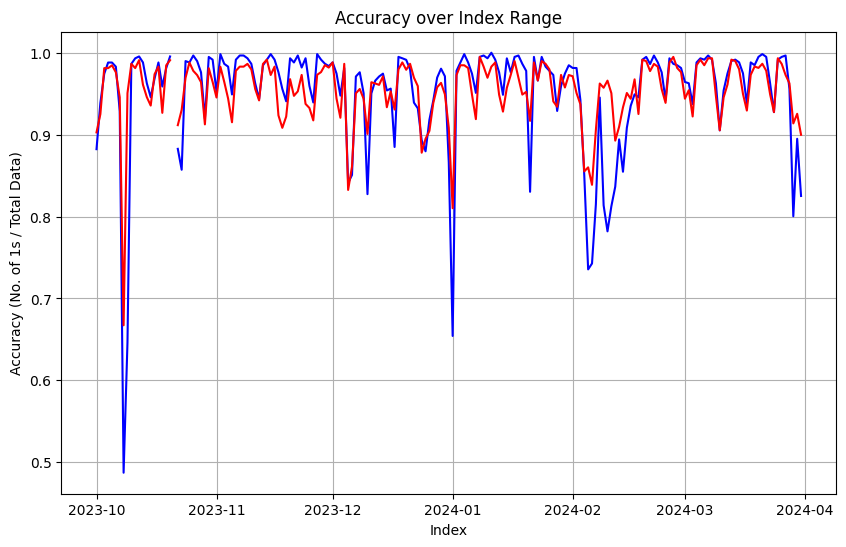

In [68]:
accuracy_1 = (df_result == 1).sum(axis=1) / df_result.notna().sum(axis=1)
accuracy_2 = (df == 1).sum(axis=1) / df.notna().sum(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(accuracy_1.index, accuracy_1.values, linestyle='-', color='b')
plt.plot(accuracy_2.index, accuracy_2.values, linestyle='-', color='r')
plt.xlabel('Index')
plt.ylabel('Accuracy (No. of 1s / Total Data)')
plt.title('Accuracy over Index Range')
plt.grid(True)
plt.show()

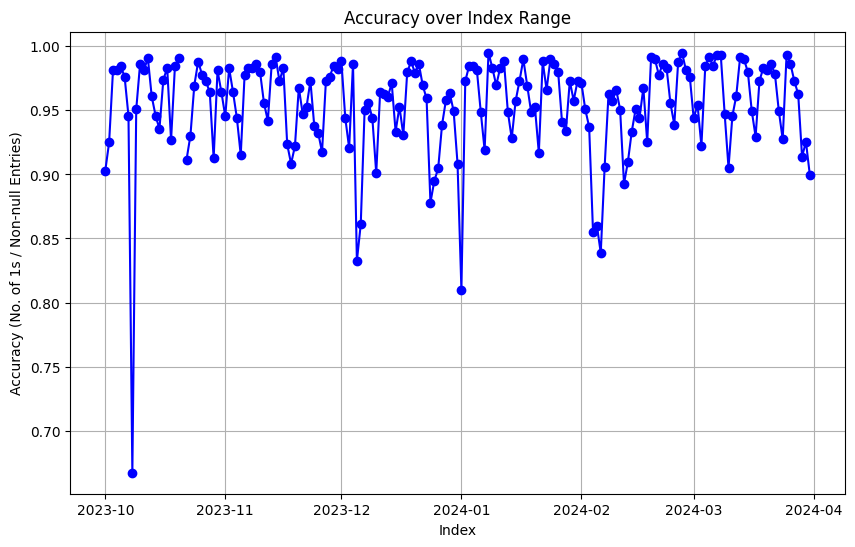

In [69]:
accuracy_2 = (df == 1).sum(axis=1) / df.notna().sum(axis=1)

# Plot the accuracy over the index range
plt.figure(figsize=(10, 6))
plt.plot(accuracy_2.index, accuracy_2.values, marker='o', linestyle='-', color='b')
plt.xlabel('Index')
plt.ylabel('Accuracy (No. of 1s / Non-null Entries)')
plt.title('Accuracy over Index Range')
plt.grid(True)
plt.show()

## Histogram of Accuracy vs Cutoff 

In [ ]:
X_0_4 = []
y_0_4 = []

X_4_7 = []
y_4_7 = []

X_7_8 = []
y_7_8 = []

X_8_9 = []
y_8_9 = []

for idx in df.index:
    for i in df.columns:
        if(df.loc[idx,i]==-1):
            corr = 0
            row_id_0 = df_triplets.index[df_triplets['0'].isin([i])]
            row_id_1 = df_triplets.index[df_triplets['1'].isin([i])]
            row_id_2 = df_triplets.index[df_triplets['2'].isin([i])]
            if(not(row_id_1.empty)):
                det = df_triplets.loc[row_id_1].values.flatten().tolist()
                t1 = det[0]+'_total_flow' in dfv.columns
                t3 = det[2]+'_total_flow' in dfv.columns

                if(t1 and t3):
                    det1 = dfv.loc[idx: idx + pd.DateOffset(days=1),det[0]+'_total_flow']
                    det2 = dfv.loc[idx: idx + pd.DateOffset(days=1),det[1]+'_total_flow']
                    det3 = dfv.loc[idx: idx + pd.DateOffset(days=1),det[2]+'_total_flow']

                    corr = (det2.corr(det1) + det2.corr(det3))/2
                elif(t1 and not(t3)):
                    det1 = dfv.loc[idx: idx + pd.DateOffset(days=1),det[0]+'_total_flow']
                    det2 = dfv.loc[idx: idx + pd.DateOffset(days=1),det[1]+'_total_flow']

                    corr = det2.corr(det1)
                elif(t3 and not(t1)):
                    det2 = dfv.loc[idx: idx + pd.DateOffset(days=1),det[1]+'_total_flow']
                    det3 = dfv.loc[idx: idx + pd.DateOffset(days=1),det[2]+'_total_flow']

                    corr = det2.corr(det3)                    

            elif(not(row_id_0.empty)):
                det = df_triplets.loc[row_id_0].values.flatten().tolist()
                det1 = dfv.loc[idx: idx + pd.DateOffset(days=1),det[0]+'_total_flow']
                det2 = dfv.loc[idx: idx + pd.DateOffset(days=1),det[1]+'_total_flow']

                corr = det2.corr(det1)

            elif(not(row_id_2.empty)):
                det = df_triplets.loc[row_id_2].values.flatten().tolist()
                det2 = dfv.loc[idx: idx + pd.DateOffset(days=1),det[1]+'_total_flow']
                det3 = dfv.loc[idx: idx + pd.DateOffset(days=1),det[2]+'_total_flow']

                corr = det2.corr(det3)

            start = idx
            end = start + pd.Timedelta(days=1) - pd.Timedelta(minutes=2)
            weekday_number = start.date().weekday()
            one_hot_day = np.eye(7)[1]

            # Get data for the current day
            daily_data = dfv[start:end][i+'_total_flow'].values

            if len(daily_data) == 720:  # Ensure we have exactly 720 samples (24 hours * 30 samples per hour)
                # Append daily data and corresponding label
                features = np.hstack((one_hot_day, daily_data))

            if(corr<0.4):
                    X_0_4.append(features)
                    y_0_4.append(one_hot_encoder.transform([[i]])[0])
            
            elif(corr<0.7):
                    X_4_7.append(features)
                    y_4_7.append(one_hot_encoder.transform([[i]])[0])

            elif(corr<0.8):
                    X_7_8.append(features)
                    y_7_8.append(one_hot_encoder.transform([[i]])[0])                  
            elif(corr<0.9):
                    X_8_9.append(features)
                    y_8_9.append(one_hot_encoder.transform([[i]])[0]) 
        

In [ ]:
X_0_4_np = np.array(X_0_4, dtype=np.float32)
y_0_4_np = np.array(y_0_4, dtype=np.float32)

X_4_7_np = np.array(X_4_7, dtype=np.float32)
y_4_7_np = np.array(y_4_7, dtype=np.float32)

X_7_8_np = np.array(X_7_8, dtype=np.float32)
y_7_8_np = np.array(y_7_8, dtype=np.float32)

X_8_9_np = np.array(X_8_9, dtype=np.float32)
y_8_9_np = np.array(y_8_9, dtype=np.float32)

# Normalize the data
X_0_4_np_normalized = scaler.fit_transform(X_0_4_np)
X_4_7_np_normalized = scaler.fit_transform(X_4_7_np)
X_7_8_np_normalized = scaler.fit_transform(X_7_8_np)
X_8_9_np_normalized = scaler.fit_transform(X_8_9_np)

# Convert normalized data to PyTorch tensors
X_0_4_tensor = torch.tensor(X_0_4_np_normalized)
y_0_4_tensor = torch.tensor(y_0_4_np, dtype=torch.float32)  # Assuming y is a regression target, if classification, use long

X_4_7_tensor = torch.tensor(X_4_7_np_normalized)
y_4_7_tensor = torch.tensor(y_4_7_np, dtype=torch.float32)

X_7_8_tensor = torch.tensor(X_7_8_np_normalized)
y_7_8_tensor = torch.tensor(y_7_8_np, dtype=torch.float32)

X_8_9_tensor = torch.tensor(X_8_9_np_normalized)
y_8_9_tensor = torch.tensor(y_8_9_np, dtype=torch.float32)

X_0_4_tensor = X_0_4_tensor.to(device)
y_0_4_tensor = y_0_4_tensor.to(device)

X_4_7_tensor = X_4_7_tensor.to(device)
y_4_7_tensor = y_4_7_tensor.to(device)

X_7_8_tensor = X_7_8_tensor.to(device)
y_7_8_tensor = y_7_8_tensor.to(device)

X_8_9_tensor = X_8_9_tensor.to(device)
y_8_9_tensor = y_8_9_tensor.to(device)

# Print the dimensions of the tensors
print(f"Dimensions of X_0_4_tensor: {X_0_4_tensor.shape}")
print(f"Dimensions of y_0_4_tensor: {y_0_4_tensor.shape}")

print(f"Dimensions of X_4_7_tensor: {X_4_7_tensor.shape}")
print(f"Dimensions of y_4_7_tensor: {y_4_7_tensor.shape}")

print(f"Dimensions of X_7_8_tensor: {X_7_8_tensor.shape}")
print(f"Dimensions of y_7_8_tensor: {y_7_8_tensor.shape}")

print(f"Dimensions of X_8_9_tensor: {X_8_9_tensor.shape}")
print(f"Dimensions of y_8_9_tensor: {y_8_9_tensor.shape}")

Dimensions of X_0_4_tensor: torch.Size([97, 727])
Dimensions of y_0_4_tensor: torch.Size([97, 529])
Dimensions of X_4_7_tensor: torch.Size([171, 727])
Dimensions of y_4_7_tensor: torch.Size([171, 529])
Dimensions of X_7_8_tensor: torch.Size([431, 727])
Dimensions of y_7_8_tensor: torch.Size([431, 529])
Dimensions of X_8_9_tensor: torch.Size([1567, 727])
Dimensions of y_8_9_tensor: torch.Size([1567, 529])


In [ ]:
top5_accuracies = []

# Loop through each dataframe and compute top-5 accuracy
for X_tensor, y_tensor in [(X_0_4_tensor, y_0_4_tensor),
                           (X_4_7_tensor, y_4_7_tensor),
                           (X_7_8_tensor, y_7_8_tensor),
                           (X_8_9_tensor, y_8_9_tensor),
                           (X_test_tensor, y_test_tensor)]:

    with torch.no_grad():
        outputs = model(X_tensor)
        total_predictions = y_tensor.size(0)
        _, predicted = torch.topk(outputs, 5, dim=1)
        correct_predictions = (y_tensor.gather(1, predicted) == 1).any(dim=1).sum().item()
        accuracy = correct_predictions / total_predictions
        top5_accuracies.append(accuracy)

# Print or use top5_accuracies as needed
for i, accuracy in enumerate(top5_accuracies):
    print(f"Top-5 Accuracy for DataFrame {i+1}: {accuracy}")

Top-5 Accuracy for DataFrame 1: 0.010309278350515464
Top-5 Accuracy for DataFrame 2: 0.08187134502923976
Top-5 Accuracy for DataFrame 3: 0.08816705336426914
Top-5 Accuracy for DataFrame 4: 0.41033822590938096
Top-5 Accuracy for DataFrame 5: 0.9240758503652328


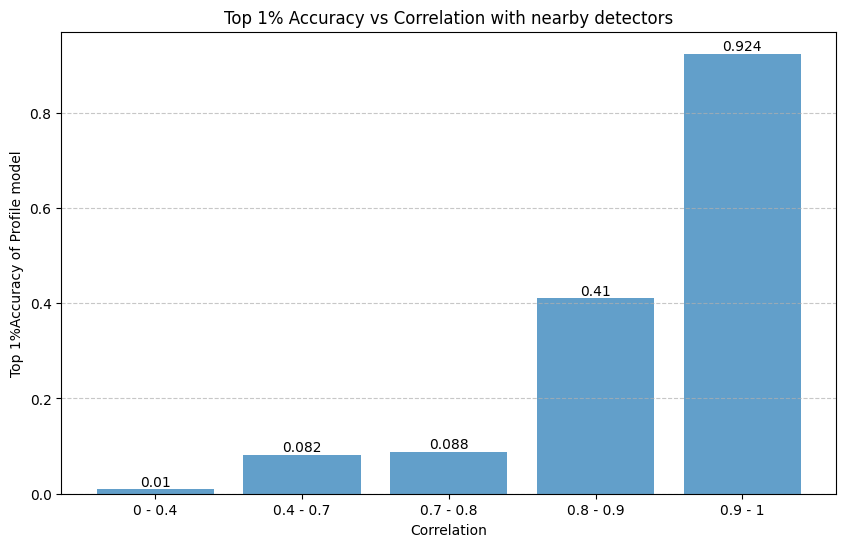

In [70]:
# top5_accuracies = [0.010309278350515464,0.08187134502923976,0.08816705336426914,0.41033822590938096,0.9240758503652328]

class_intervals = ['0 - 0.4', '0.4 - 0.7', '0.7 - 0.8', '0.8 - 0.9', '0.9 - 1']
frequencies = np.round(top5_accuracies, 3)  # Example frequencies

# Define the positions for each bar
x_pos = np.arange(len(class_intervals))

# Plotting the bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(x_pos, frequencies, align='center', alpha=0.7)

# Add frequencies as annotations
for bar, freq in zip(bars, frequencies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), str(freq), 
             ha='center', va='bottom', fontsize=10, color='black')

# Customize plot
plt.xticks(x_pos, class_intervals)
plt.xlabel('Correlation')
plt.ylabel('Top 1%Accuracy of Profile model')
plt.title('Top 1% Accuracy vs Correlation with nearby detectors')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.show()